In [116]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)
X = np.random.uniform(-5, 5 , size=(100, 2))

print(X.shape)
print(X)

(100, 2)
[[-3.0848055   1.22108771]
 [-0.62272261  2.85358584]
 [ 2.79975808 -2.27407395]
 [-2.23535745  3.01872178]
 [ 4.58139354  3.75932635]
 [-1.4218273   0.00995126]
 [ 1.83462935  2.12702027]
 [-1.29749245  0.61196186]
 [ 0.03083165 -4.8623155 ]
 [ 2.72826622  3.82641191]
 [-1.35114016  1.15396178]
 [-4.24618758 -1.31175994]
 [ 4.33140102  1.51378143]
 [-1.02797422  2.88730143]
 [-1.83163878  0.68098653]
 [ 3.6912739  -0.63826576]
 [ 3.02147642 -3.56233175]
 [ 2.04260971  2.04581308]
 [-2.81207894  4.24867629]
 [-0.57859245  4.09315959]
 [-4.40190777 -3.15712916]
 [-4.52644721  1.74880944]
 [ 0.9462478   0.33310163]
 [-4.56675937  0.6143308 ]
 [-1.70331554  0.02966833]
 [-3.88105682  1.07193706]
 [ 0.65944643 -4.93235938]
 [ 1.17441709  4.12122886]
 [ 2.90524133  4.92081466]
 [ 4.58801762  2.91964135]
 [-2.1474904   1.24916705]
 [-0.21906204 -3.04324821]
 [-1.17682548 -4.46126315]
 [-0.48351592  4.82004742]
 [-3.760573   -3.80619102]
 [ 2.38523056  0.87303633]
 [-0.28367466 -3.92

In [117]:
x_1 = X[:,0]
x_2 = X[:,1]
m=0.5
b=0

print(x_1)
print(x_2)

[-3.0848055  -0.62272261  2.79975808 -2.23535745  4.58139354 -1.4218273
  1.83462935 -1.29749245  0.03083165  2.72826622 -1.35114016 -4.24618758
  4.33140102 -1.02797422 -1.83163878  3.6912739   3.02147642  2.04260971
 -2.81207894 -0.57859245 -4.40190777 -4.52644721  0.9462478  -4.56675937
 -1.70331554 -3.88105682  0.65944643  1.17441709  2.90524133  4.58801762
 -2.1474904  -0.21906204 -1.17682548 -0.48351592 -3.760573    2.38523056
 -0.28367466 -2.70781435 -0.83246462 -4.93791483 -0.63106828  4.18198075
  2.05997565  2.46063409  1.33725769 -3.47427225  0.28224278 -0.19640821
  0.36878193 -4.42884362  2.67116628  2.96867184  4.65836532 -4.70352999
 -3.85934301 -1.74292586 -0.42188351  3.79069162 -1.51991207  4.01796051
  2.26658462  2.79163801 -2.08874755 -1.64825341 -4.26657456 -1.76805186
  3.53898567 -3.26932773  4.94653829 -1.82453177 -4.90651425  4.77241431
 -4.15226157  2.28428676  0.52468939  4.74495138 -2.44346714  2.76180723
  2.61603914  1.58622782 -2.98244308  4.5219541   4.

In [118]:
y = np.where(x_2>m*x_1+b, 1, 0)

print(y)

[1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 0 1 0 0 0
 1 1 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0
 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1]


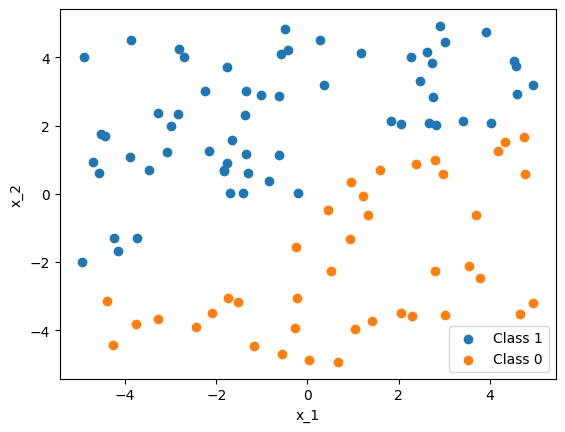

In [119]:
fig, ax = plt.subplots()
ax.scatter(x_1[y == 1], x_2[y == 1], label="Class 1")
ax.scatter(x_1[y == 0], x_2[y == 0], label="Class 0")
ax.legend()
ax.set_label("2D dataset")
ax.set_xlabel("x_1")
ax.set_ylabel("x_2")

plt.show()

In [143]:
class Perceptron:
    def __init__(self, learning_rate=0.01, iterations=2):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.errors = []

    def fit(self, X, y):
        samples, features =X.shape 
        self.weights = np.zeros(features)
        self.bias = 0

        for _ in range(self.iterations):
            errors = 0

            for i, y_target in zip(X, y):
                y_pred = self.predict(i)

                update = self.learning_rate * (y_target - y_pred)

                self.weights = self.weights + update * i

                self.bias = self.bias + update

                errors += int(update != 0.0)

            self.errors.append(errors)
        return self

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

In [144]:
model = Perceptron()

model.fit(X, y)

print("Learned weights:", model.weights)
print("Learned bias:", model.bias)

Learned weights: [-0.07113388  0.11226852]
Learned bias: 0.04


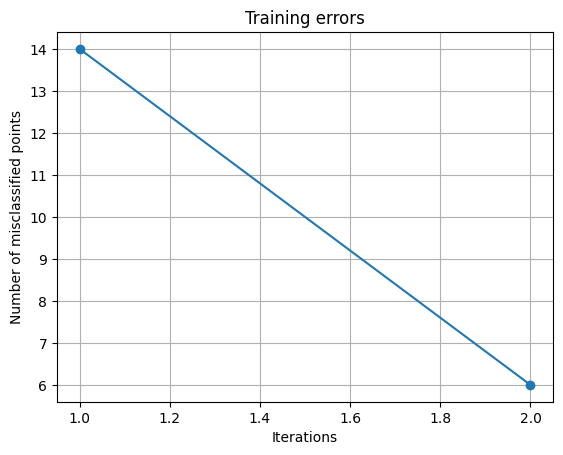

In [145]:
fig, ax = plt.subplots()

ax.plot(range(1, model.iterations + 1), model.errors, marker="o")

ax.set_xlabel("Iterations")
ax.set_ylabel("Number of misclassified points")
ax.set_title("Training errors")
ax.grid(True)
plt.show()

In [146]:
predictions = model.predict(X)

accuracy = np.mean(predictions == y)

print(f"Training accuracy: {accuracy * 100:.2f}%")

Training accuracy: 97.00%


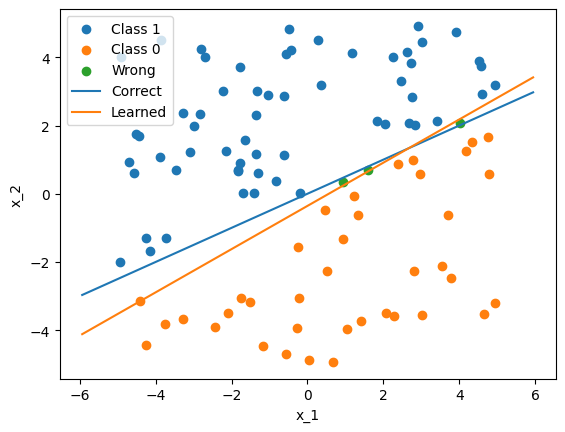

In [148]:
fig, ax = plt.subplots()
ax.scatter(x_1[(predictions == 1) & (y == 1)], x_2[(predictions == 1) & (y == 1)], label="Class 1")
ax.scatter(x_1[(predictions == 0) & (y == 0)], x_2[(predictions == 0) & (y == 0)], label="Class 0")
ax.scatter(x_1[predictions != y], x_2[predictions != y], label="Wrong")

x_values = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
correct_line = m * x_values + b

ax.plot(x_values, correct_line, label="Correct")

w1 = model.weights[0]
w2 = model.weights[1]
b = model.bias


learned_line = -(w1 * x_values +b) / w2
ax.plot(x_values,
        learned_line,
        label="Learned")
    


ax.legend()
ax.set_label("2D dataset")
ax.set_xlabel("x_1")
ax.set_ylabel("x_2")

plt.show()